<a href="https://colab.research.google.com/github/TaShapovalova/my-colab-project/blob/main/MODULE2_for_TUSUR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ВЫПОЛНИТЬ УСТАНОВКУ БИБЛИОТЕКИ  gensim И ПЕРЕЗАПУСТИТЬ СЕАНС: главное меню-->Среда выполнения->Перезапустить сеанс.

!pip install gensim
#ПОСЛЕ ПЕРЕЗАПУСКА СЕАНСА повторно эту строку выполнять не нужно

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.5 MB/s eta 0:00:00


In [ ]:
#используемые библиотеки
import networkx # работа с графом

import pandas as pd

from tqdm import tqdm #отслеживание прогресса выполнения

import numpy as np

import random
from random import randint

from gensim.models import Word2Vec #word2vec
import warnings

#снижение размерности для визуализации
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


from sklearn import metrics # метрики качества кластерного анализа

In [ ]:
from google.colab import files
import pandas as pd
import networkx as nx

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  if fn.endswith('.graphml'):
    try:
      G = nx.read_graphml(fn)
      print(f"Successfully loaded graph '{fn}'.")
      print(f"Number of nodes: {G.number_of_nodes()}")
      print(f"Number of edges: {G.number_of_edges()}")
      print("First 5 nodes:")
      for i, node in enumerate(G.nodes()):
          if i >= 5:
              break
          print(node, G.nodes[node])

    except Exception as e:
      print(f"Error reading GraphML file {fn}: {e}")
  else:
    # Fallback for other file types if user uploads something else later
    try:
      df = pd.read_csv(fn)
      print("First 5 rows of the dataset:")
      print(df.head())
    except Exception as e:
      print(f"Error reading file {fn}: {e}")
      print("Attempting to read as Excel...")
      try:
          df = pd.read_excel(fn)
          print("First 5 rows of the dataset:")
          print(df.head())
      except Exception as e_excel:
          print(f"Error reading file {fn} as Excel: {e_excel}")
          print("Could not read the file. Please ensure it's a CSV, Excel, or GraphML file and try again.")

Saving graph_dataset.graphml to graph_dataset.graphml
User uploaded file "graph_dataset.graphml"
First 5 rows of the dataset:
              <?xml version='1.0' encoding='utf-8'?>
0  <graphml xmlns="http://graphml.graphdrawing.or...
1  <key id="d1" for="edge" attr.name="weight" att...
2  <key id="d0" for="node" attr.name="class" attr...
3      <graph edgedefault="undirected"><node id="1">
4                            <data key="d0">2</data>


In [ ]:
G=None
# 1. ВСТАВИТЬ КОД
# вставьте программный код сюда, прочитав исходнные данные в переменную G
#G =

In [ ]:
# G - граф, структура networkx
# dk - узлы степень меньше или равной которой следует удалить.
def onion_peel(G, dk):
  G1 = G.copy()
  f=0
  while f!=1:
    f=1
    for v in list(G1.nodes()):
      # 2. ВСТАВИТЬ КОД #############
      # вставьте код тут ~3 строки
      # Если степень узла v меньше или равна заданной, то данный узел следует удалить и обнулить флаг f.
      if G1.degree(v) <= dk:
        G1.remove_node(v)
        f = 0


      ##########################################
  return G1

In [ ]:
import networkx as nx
G = nx.read_graphml('/content/graph_dataset.graphml') # Temporarily load G here to fix the error in this cell.

nodes_number_before = len(G.nodes ) # оценим сколько было узлов до удаления
G1 = onion_peel(G,2) # применим реализованную функцию
# расчитайте сколько узлов осталось  ~ 1 строка кода
number_del = nodes_number_before - len(G1.nodes)

In [ ]:
import networkx
import random

# t - максимальная длина цепочки, построенной в ходе случайных блужданий
def get_randomwalk(G, node, t):

    random_walk = [node]
    #print ('начинаем с узла', random_walk)
    for i in range(t-1):
        temp = [] # Initialize temp as an empty list
        # 4 ВСТАВИТЬ КОД
        # вставить программный код тут ~ 1 строка кода, в переменную temp получите соседей узла node при помощи функции neigbors
        try:
            temp = list(G.neighbors(node))
        except KeyError:
            # If the node is not in the graph, it has no neighbors. temp remains an empty list.
            pass
        except Exception as e:
            # Catch any other unexpected errors and ensure temp is a list
            print(f"Warning: Unexpected error while getting neighbors for node {node}: {e}")
            temp = []

        # print('соседи', temp)
        if len(temp) == 0:
            break

        random_node = random.choice(temp)  # случайно сделаем шаг в следующий узел
        random_walk.append(random_node)
        node = random_node

    return random_walk

In [ ]:
#необходимые библиотеки обозначены в комментариях
#from tqdm import tqdm
#import random

all_nodes = list(G1.nodes())
gamma = 80 # число случайных блужданий приходящихся на 1 узел. т.е. для каждого узла стартуем gamma раз
t = 80 # максимальная длина цепочки
random_walks = []
for n in tqdm(all_nodes):
    for i in range(gamma):
        random_walks.append(get_randomwalk(G1, n, t))

# полученное число случайных блужданий
len(random_walks)

100%|██████████| 2274/2274 [00:38<00:00, 59.00it/s]


181920

In [ ]:
model = Word2Vec(window = 5, sg = 1, hs = 1, batch_words=3000,
                 negative = 0, # for negative sampling
                 alpha=0.03, min_alpha=0.0001,
                 seed = 14, workers=4 ,vector_size=300, compute_loss=True)

model.build_vocab(random_walks, progress_per=2)
model.train(random_walks, total_examples = model.corpus_count, epochs=2, report_delay=1)

(27608834, 29107200)

In [ ]:
model.save("skipgram_2k.model")

#model = Word2Vec.load("skipgram_2k.model")

In [ ]:
model.wv.key_to_index # первое значение это исходный номер узла, второе это индекс узла.

{'761': 0,
 '729': 1,
 '1830': 2,
 '1019': 3,
 '1344': 4,
 '1654': 5,
 '848': 6,
 '2763': 7,
 '547': 8,
 '903': 9,
 '88': 10,
 '1955': 11,
 '710': 12,
 '464': 13,
 '676': 14,
 '1001': 15,
 '1591': 16,
 '1335': 17,
 '2351': 18,
 '2427': 19,
 '856': 20,
 '1309': 21,
 '785': 22,
 '1766': 23,
 '625': 24,
 '1822': 25,
 '1481': 26,
 '2038': 27,
 '1585': 28,
 '1426': 29,
 '1935': 30,
 '926': 31,
 '445': 32,
 '63': 33,
 '706': 34,
 '1548': 35,
 '598': 36,
 '214': 37,
 '1929': 38,
 '1083': 39,
 '1880': 40,
 '743': 41,
 '850': 42,
 '461': 43,
 '1433': 44,
 '832': 45,
 '1710': 46,
 '1783': 47,
 '1220': 48,
 '1056': 49,
 '632': 50,
 '2926': 51,
 '1593': 52,
 '983': 53,
 '1371': 54,
 '199': 55,
 '793': 56,
 '633': 57,
 '730': 58,
 '688': 59,
 '3007': 60,
 '2935': 61,
 '1401': 62,
 '1406': 63,
 '1223': 64,
 '1712': 65,
 '79': 66,
 '2844': 67,
 '1229': 68,
 '873': 69,
 '2933': 70,
 '565': 71,
 '496': 72,
 '1936': 73,
 '1518': 74,
 '2463': 75,
 '609': 76,
 '1136': 77,
 '1841': 78,
 '1776': 79,
 '693':

In [ ]:
# получем список узлов, из самой модели
keys = model.wv.key_to_index.keys()
keys

dict_keys(['761', '729', '1830', '1019', '1344', '1654', '848', '2763', '547', '903', '88', '1955', '710', '464', '676', '1001', '1591', '1335', '2351', '2427', '856', '1309', '785', '1766', '625', '1822', '1481', '2038', '1585', '1426', '1935', '926', '445', '63', '706', '1548', '598', '214', '1929', '1083', '1880', '743', '850', '461', '1433', '832', '1710', '1783', '1220', '1056', '632', '2926', '1593', '983', '1371', '199', '793', '633', '730', '688', '3007', '2935', '1401', '1406', '1223', '1712', '79', '2844', '1229', '873', '2933', '565', '496', '1936', '1518', '2463', '609', '1136', '1841', '1776', '693', '119', '941', '2307', '45', '1522', '1023', '2022', '1440', '2668', '739', '457', '2857', '28', '1118', '586', '701', '637', '420', '2839', '487', '543', '1713', '740', '1326', '84', '2551', '2007', '1910', '2894', '2345', '727', '1663', '525', '610', '2429', '3034', '657', '1551', '1798', '1330', '2532', '2709', '1506', '2695', '1016', '2129', '480', '1668', '261', '993', '21

In [ ]:
model.wv.vectors # тут содержаться все векторные представления. Векторные представления идут по порядку ключей keys

array([[ 0.06015185,  0.11231169, -0.01059164, ..., -0.05021108,
        -0.08029659, -0.20748015],
       [ 0.1526791 ,  0.13903132,  0.0815222 , ...,  0.01099904,
         0.02362534, -0.02703731],
       [ 0.03605007, -0.08389537,  0.09419269, ...,  0.09045096,
        -0.03196321,  0.20074412],
       ...,
       [ 0.0390011 ,  0.05162833, -0.04446844, ...,  0.19589087,
         0.10540418, -0.02341923],
       [ 0.26541686, -0.03174311, -0.24427052, ..., -0.3067959 ,
         0.38479012, -0.16958857],
       [ 0.13483553,  0.1357915 , -0.1636609 , ...,  0.0026268 ,
         0.09580364,  0.05045493]], dtype=float32)

In [ ]:
model.wv.vectors.shape # размер матрицы векторных представлений

(2274, 300)

In [ ]:
# 5. ВСТАВИТЬ КОД
# ~1 строка кода выведете класс узла 2652

In [ ]:
X_emb = []
y = []
for i in keys:
  X_emb.append(   model.wv.__getitem__(i)  )
  y.append(G.nodes[i]['class'])

In [ ]:
# сформируем датафрейм номер узла и класс
d = {'id_node':keys,'y':y}
df = pd.DataFrame(d)
df

,id_node,y
0,761,3
1,729,3
2,1830,3
3,1019,1
4,1344,1
...,...,...
2269,2585,4
2270,3036,4
2271,1236,1
2272,2982,2


<Axes: >

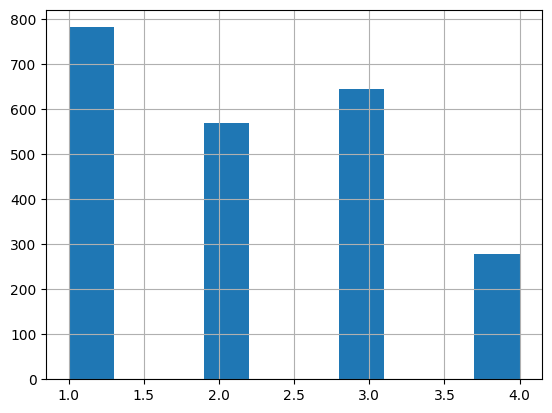

In [ ]:
df.y.hist() # распределение по классам

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression

scoring = {'f1_score_micro' : make_scorer(f1_score, average='micro'), 'f1_score_macro' : make_scorer(f1_score, average='macro') }
kfold = KFold(n_splits=4, random_state=14, shuffle=True)
f1 = make_scorer(f1_score, average='micro')
rf=RandomForestClassifier(  random_state=14)

scores = cross_validate(rf, X_emb, y, cv=kfold,  scoring=scoring)
print("F1 macro ", np.average(scores['test_f1_score_macro']))
print("F1 micro ", np.average(scores['test_f1_score_micro']))

F1 macro  0.6579723230519128
F1 micro  0.7040458922250551


In [ ]:
#библиотеки для визуализации данных по векторному представлению на плоскости
!pip install umap
!pip install umap-learn

ERROR: Could not find a version that satisfies the requirement umap (from versions: none)
ERROR: No matching distribution found for umap


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


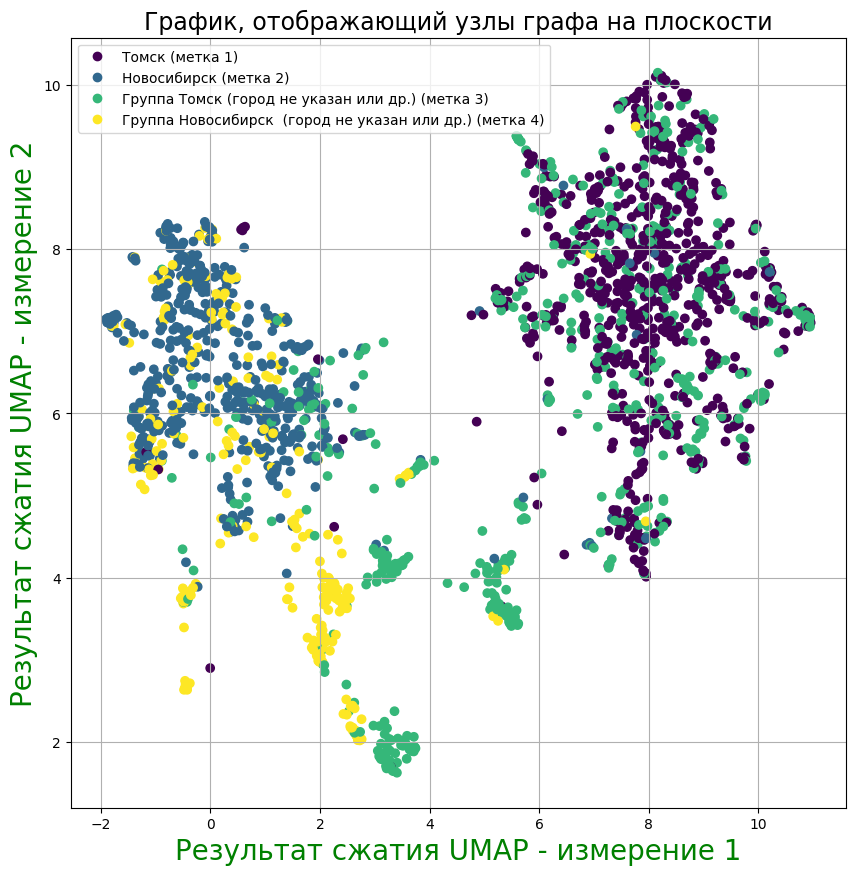

In [ ]:
import umap.umap_ as umap
u =umap.UMAP(random_state=14, n_neighbors=20, metric='cosine')
embed = X_emb
umap_embs = u.fit_transform(embed)
values = [x-1 for x in y]

plt.figure(3,figsize=(10,10))
plt.title('График, отображающий узлы графа на плоскости', fontsize=17)
ax = plt.scatter(x=umap_embs[:, 0], y=umap_embs[:, 1],   c=values)
plt.xlabel("Результат сжатия UMAP - измерение 1", fontsize = 20, c = "green")
plt.ylabel("Результат сжатия UMAP - измерение 2", fontsize = 20, c = "green")

plt.legend(handles=ax.legend_elements()[0], labels=['Томск (метка 1)', 'Новосибирск (метка 2)', 'Группа Томск (город не указан или др.) (метка 3)', 'Группа Новосибирск  (город не указан или др.) (метка 4)'])
plt.grid(True)

In [ ]:
# установка библиотеки для использования k-medoids
#!pip install https://github.com/scikit-learn-contrib/scikit-learn-extra/archive/master.zip # для numpy <2
!pip install git+https://github.com/TimotheeMathieu/scikit-learn-extra  # для numpy >2

  Cloning https://github.com/TimotheeMathieu/scikit-learn-extra to /tmp/pip-req-build-d4_gggr3
  Running command git clone --filter=blob:none --quiet https://github.com/TimotheeMathieu/scikit-learn-extra /tmp/pip-req-build-d4_gggr3
  Resolved https://github.com/TimotheeMathieu/scikit-learn-extra to commit 21f5aa70c18e4615aaf700905014e9bf84c0d4f3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0.dev0-cp312-cp312-linux_x86_64.whl size=1969057 sha256=a41814f2c04325468ef03933b530bc1b6c62662457029a1b41f2f80e1b20a62b
  Stored in directory: /tmp/pip-ephem-wheel-cache-dbeedpfq/wheels/bd/c8/66/35929f3b27f745b6458dcf06b683d10c00e130b6e462182f5c
Successfully built scikit-learn-extra


In [ ]:
# data - массив признаков - исходные данные для кластерного анализа
# max_k максимальное число кластеров
# у - метки класса для объектов (правильные ответы). Эти данные нужны только для вычисления AMI.
# output_steps_results = true - выводить критерии качества на каждом шаге.

def find_optimal_clusters(data, max_k, y, output_steps_results = True, random_state=14):
    iters = range(2, max_k+1, 1)
    s = []
    sse = []
    max_s =-1
    max_ami = -1
    ami=""
    ss=""

    for k in iters:

      kmedoids = None
      kmedoids = KMedoids(n_clusters=k, random_state=random_state, metric='cosine').fit(data)
      s.append(metrics.silhouette_score( X=data,  metric='cosine',  random_state=random_state, labels= kmedoids.labels_ ))
      sse.append(kmedoids.inertia_)
      if output_steps_results:
        print('Fit {} clusters'.format(k))
        print ( " силуэт ",  metrics.silhouette_score( X=data,  metric='cosine', random_state=random_state,  labels= kmedoids.labels_ ), ", AMI -  ", metrics.adjusted_mutual_info_score( kmedoids.labels_, y ) )

      if (max_s < metrics.silhouette_score( X=data,  metric='cosine',   labels= kmedoids.labels_ )):
        max_s = metrics.silhouette_score( X=data,  metric='cosine',   labels= kmedoids.labels_)
        ss = "k " + str(k) + " Силуэт " + str(metrics.silhouette_score( X=data,  metric='cosine',   labels= kmedoids.labels_ ))  + ", AMI " +str( metrics.adjusted_mutual_info_score( kmedoids.labels_, y ) )

      if (max_ami < metrics.adjusted_mutual_info_score( kmedoids.labels_, y )):
        max_ami = metrics.adjusted_mutual_info_score( kmedoids.labels_, y )
        ami = "k " + str(k) + " Силуэт " + str(metrics.silhouette_score( X=data,  metric='cosine',   labels= kmedoids.labels_ ))  + ", AMI " +str( metrics.adjusted_mutual_info_score( kmedoids.labels_, y ) )


    print("---ИТОГОВЫЕ ЗНАЧЕНИЯ--------------------")
    print("Самое большое значение метрики \"Силуэт\"" , ss)
    print("Самое большое значение по  AMI" , ami)

    f, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].plot(iters, sse, marker='o')
    ax[0].set_xlabel('Число кластеров')
    ax[0].set_xticks(iters)
    ax[0].set_xticklabels(iters)
    ax[0].set_ylabel('SSE')
    ax[0].set_title('SSE в зависимости от числа кластеров')

    ax[1].plot(iters, s, marker='o')
    ax[1].set_xlabel('Число кластеров')
    ax[1].set_xticks(iters)
    ax[1].set_xticklabels(iters)
    ax[1].set_ylabel('Силуэт')
    ax[1].set_title('Силуэт в зависимости от числа кластеров')
    plt.show()

In [ ]:
# 9. ВСТАВИТЬ КОД - УКАЗАТЬ ЗНАЧЕНИЕ n_clusters
                   # укажите значение кластера с лучшим значением метрики качества т.е. значение n_clusters
# также самостоятельно можно посмотреть на то, как разбивает метод на кластеры при других значениях   n_clusters
kmedoids = KMedoids(n_clusters=2, random_state=14, metric='cosine').fit(X_emb)

In [ ]:
#визуализирум полученные данные в ходе кластерного анализа и определим для этого специальную функцию
# umap_embs_f сжатые до размерности 2  данные для визуализации
# cluster_labels - метки кластеров
# y_labels в формате values = [x-1 for x in y]
def draw_cluster(umap_embs_f, cluster_labels, y_labels):
  n_label =  sorted(list(set(cluster_labels)))
  lb = []
  for i in n_label:
    lb.append("Кластер " + str(i))


  f, ax = plt.subplots(1, 2, figsize=(15, 8))
  scat0 =ax[0].scatter (umap_embs_f[:, 0], y = umap_embs_f[:, 1], c = cluster_labels, cmap='viridis_r')
  ax[0].set_xlabel('Измерение 1')
  ax[0].set_ylabel('Измерение 2')
  ax[0].set_title('Результаты кластеризации методом k-medoids')
  ax[0].legend(handles=scat0.legend_elements()[0], labels=lb)
  ax[0].grid(True)

  scat1 = ax[1].scatter(x = umap_embs_f[:, 0], y = umap_embs_f[:, 1], c = y_labels, cmap='plasma')
  ax[1].set_xlabel('Измерение 1')
  ax[1].set_ylabel('Измерение 2')
  ax[1].set_title('Истинная разметка по классам')
  ax[1].legend(handles=scat1.legend_elements()[0], labels=['Томск (метка 1)', 'Новосибирск (метка 2)', 'Группа Томск (город не указан или др.) (метка 3)', 'Группа Новосибирск  (город не указан или др.) (метка 4)'])
  ax[1].grid(True)
  plt.show()

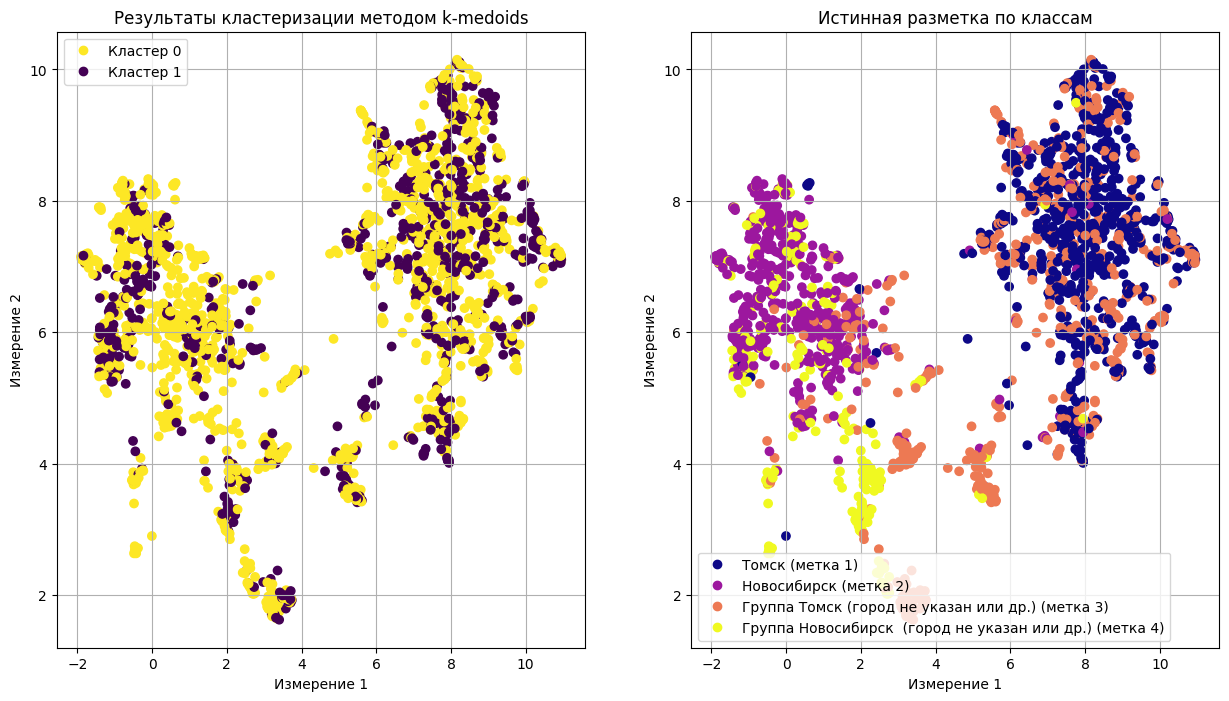

In [ ]:
draw_cluster(umap_embs, kmedoids.labels_, values)

In [ ]:
# data - массив признаков - исходные данные для кластерного анализа
# max_k максимальное число кластеров
# у - метки класса для объектов (правильные ответы). Эти данные нужны только для вычисления AMI.
# output_steps_results = true - выводить критерии качества на каждом шаге.
from sklearn.cluster import AgglomerativeClustering
def Aglomerative_f(data, max_k, y, random_state=14,output_steps_results = True):
    iters = range(2, max_k+1, 1)
    s = []
    max_s =-1
    max_ami = -1
    ami=""
    ss=""

    for k in iters:

      aglomerative = None
      aglomerative = AgglomerativeClustering(n_clusters=k,  metric='cosine', linkage='average').fit(data)
      silhouette =metrics.silhouette_score( X=data,  metric='cosine', random_state=random_state,  labels= aglomerative.labels_ )
      amik =  metrics.adjusted_mutual_info_score( aglomerative.labels_, y )
      s.append(silhouette)
      if output_steps_results:
        print('Fit {} clusters'.format(k))
        print ( " силуэт ", silhouette , ", AMI -  ", amik )

      if (max_s < silhouette ):
        max_s = silhouette
        ss = "k " + str(k) + " Силуэт " + str(silhouette)  + ", AMI " +str( amik)

      if (max_ami < amik):
        max_ami =amik
        ami =  "k " + str(k) + " Силуэт " + str(silhouette)  + ", AMI " +str( amik)


    print("---ИТОГОВЫЕ ЗНАЧЕНИЯ--------------------")
    print("Самое большое значение метрики \"Силуэт\"" , ss)
    print("Самое большое значение по  AMI" , ami)

    f, ax = plt.subplots( figsize=(10, 5))
    ax.plot(iters, s, marker='o')
    ax.set_xlabel('Число кластеров')
    ax.set_xticks(iters)
    ax.set_xticklabels(iters)
    ax.set_ylabel('Силуэт')
    ax.set_title('Силуэт в зависимости от числа кластеров')
    plt.show()

Fit 2 clusters
 силуэт  0.06249192 , AMI -   0.4011694009502022
Fit 3 clusters
 силуэт  0.053662837 , AMI -   0.4560023612475679
Fit 4 clusters
 силуэт  0.04337988 , AMI -   0.41456326483270906
Fit 5 clusters
 силуэт  0.037273787 , AMI -   0.4153577717257053
Fit 6 clusters
 силуэт  0.031682987 , AMI -   0.4133251308091276
Fit 7 clusters
 силуэт  0.03580518 , AMI -   0.37699226233070154
Fit 8 clusters
 силуэт  0.03574148 , AMI -   0.367177967772833
Fit 9 clusters
 силуэт  0.033287503 , AMI -   0.3651265886882851
Fit 10 clusters
 силуэт  0.035504166 , AMI -   0.35681658097626007
---ИТОГОВЫЕ ЗНАЧЕНИЯ--------------------
Самое большое значение метрики "Силуэт" k 2 Силуэт 0.06249192, AMI 0.4011694009502022
Самое большое значение по  AMI k 3 Силуэт 0.053662837, AMI 0.4560023612475679


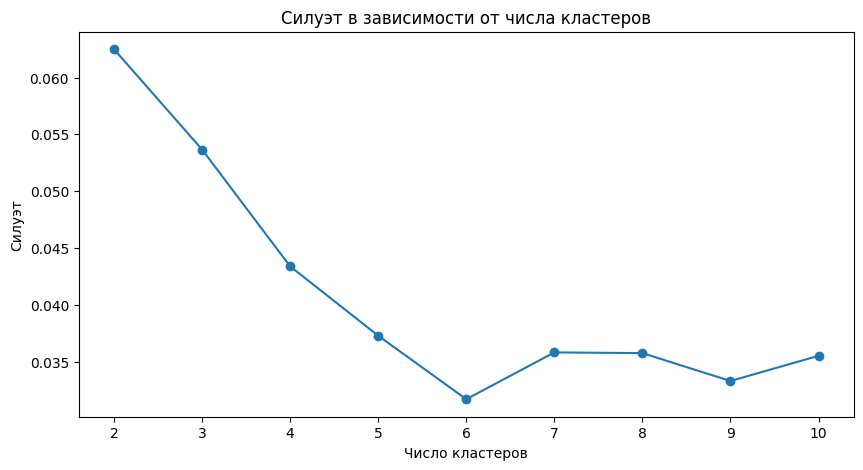

In [ ]:
Aglomerative_f(X_emb, 10, y)

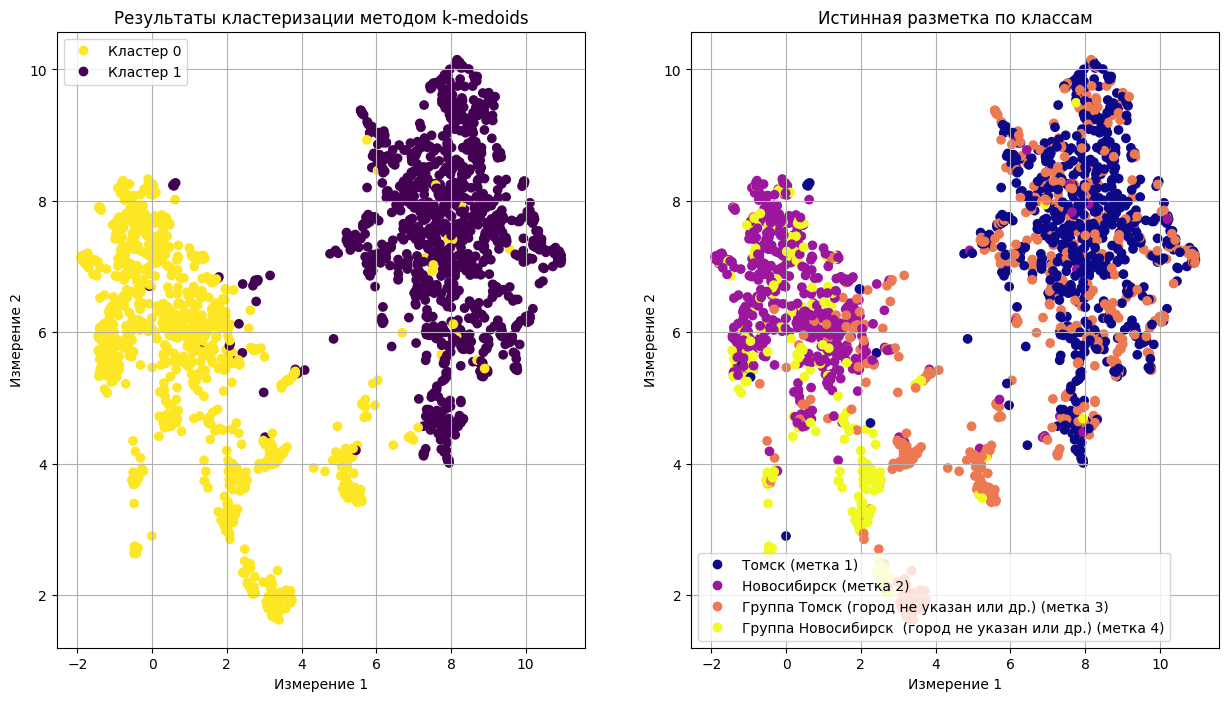

In [ ]:
agglomerative = AgglomerativeClustering(n_clusters=2,  metric='cosine', linkage='average').fit(X_emb)
draw_cluster(umap_embs, agglomerative.labels_, values)

In [ ]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=40, metric="cosine")
neighbors_fit = neighbors.fit(X_emb)
distances, indices = neighbors_fit.kneighbors(X_emb)

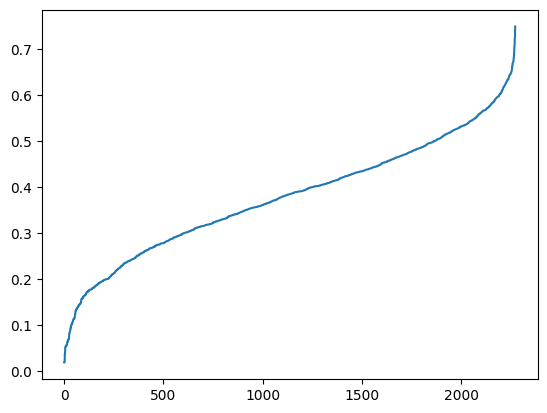

In [ ]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]

plt.plot(distances)

In [ ]:
from sklearn import metrics
def DBScan_f(X, Y, mins=20, maxs=400,  step=20, epsmin=0.1, epsmax=0.6, eps_step = 0.05, random_state = 14, output_steps_results=True):
  max_s =-1
  max_ami = -1
  ami= ""
  ss= ""
  for mins  in range(mins, maxs, step):
    for eps in np.arange(epsmin, epsmax, eps_step):
      db = DBSCAN(eps=eps, min_samples=mins, metric='cosine').fit(X)
      labels = db.labels_
      if (len(set(labels))>1):
        silhoette = metrics.silhouette_score( X=X,  metric='cosine',   labels= labels , random_state=random_state)
        ami_current = metrics.adjusted_mutual_info_score( labels, y )
        if output_steps_results == True:
           print ("mins ", mins, "eps ", eps,  set(labels), " силуэт " , str(silhoette), ", AMI ", ami_current , ", davies_bouldin ", metrics.davies_bouldin_score(X=X, labels= labels))
        if (max_s < silhoette):
          max_s = silhoette
          ss = "mins " + str(mins) + ", eps "+ str(eps) + " Силуэт " + str(silhoette)  + ", AMI " +str(ami_current )

        if (max_ami < ami_current):
          max_ami = ami_current
          ami =  "mins " + str(mins) + ", eps "+ str(eps) + " Силуэт " + str(silhoette)  + ", AMI " +str(ami_current )
      else:
        if output_steps_results == True:
           print ("mins ", mins, "eps ", eps,  set(db.labels_), " силуэт отсутствует" )
  print("---ИТОГОВЫЕ ЗНАЧЕНИЯ--------------------")
  print("Самое большое значение метрики \"Силуэт\"" , ss)
  print("Самое большое значение по  AMI" , ami)

In [ ]:
DBScan_f(X_emb, y)

mins  20 eps  0.1 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.15000000000000002 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.20000000000000004 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.25000000000000006 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.30000000000000004 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.3500000000000001 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.40000000000000013 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.45000000000000007 {np.int64(0), np.int64(1), np.int64(-1)}  силуэт  -0.017960971 , AMI  0.03943906762469805 , davies_bouldin  2.3718645169343233
mins  20 eps  0.5000000000000001 {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}  силуэт  -0.036907073 , AMI  0.06376560964696808 , davies_bouldin  2.6131015962397797
mins  20 eps  0.5500000000000002 {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(-1)}  силуэт  -0.023677582 

In [ ]:
DBScan_f(X_emb, y)

mins  20 eps  0.1 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.15000000000000002 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.20000000000000004 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.25000000000000006 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.30000000000000004 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.3500000000000001 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.40000000000000013 {np.int64(-1)}  силуэт отсутствует
mins  20 eps  0.45000000000000007 {np.int64(0), np.int64(1), np.int64(-1)}  силуэт  -0.017960971 , AMI  0.03943906762469805 , davies_bouldin  2.3718645169343233
mins  20 eps  0.5000000000000001 {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}  силуэт  -0.036907073 , AMI  0.06376560964696808 , davies_bouldin  2.6131015962397797
mins  20 eps  0.5500000000000002 {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(-1)}  силуэт  -0.023677582 

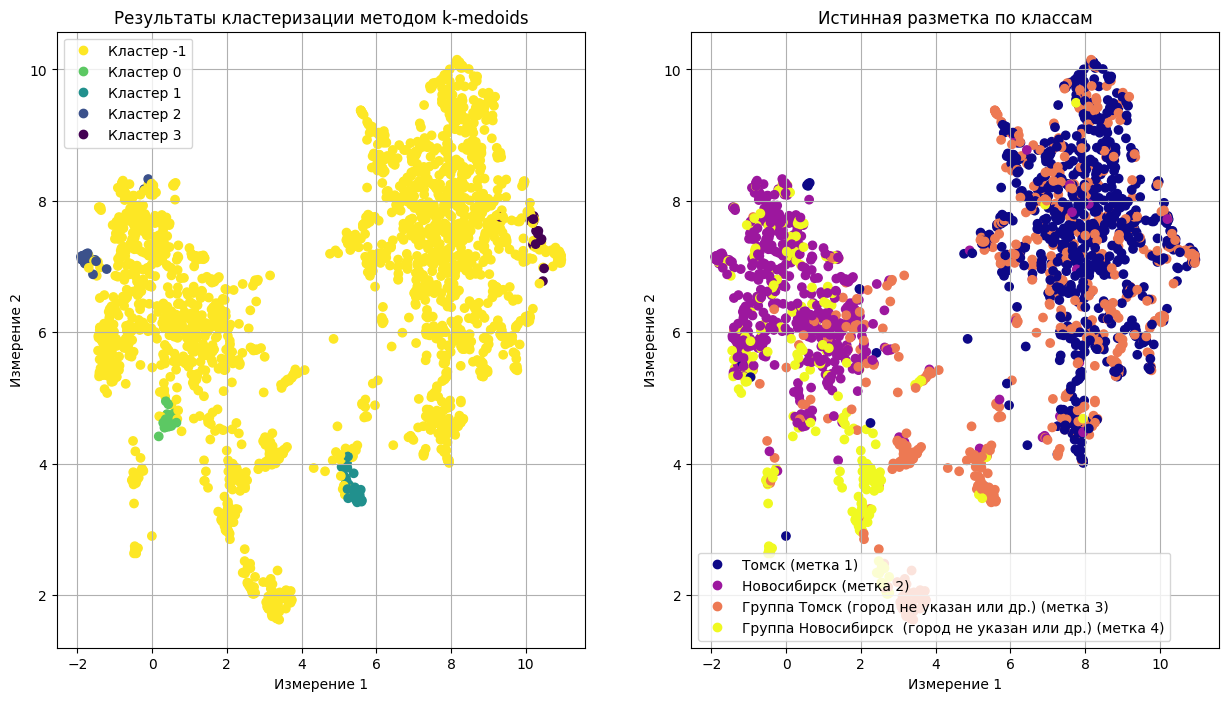

In [ ]:
db = DBSCAN(eps=0.5, min_samples=20, metric='cosine' ).fit(X_emb)
draw_cluster(umap_embs,  db.labels_, values)

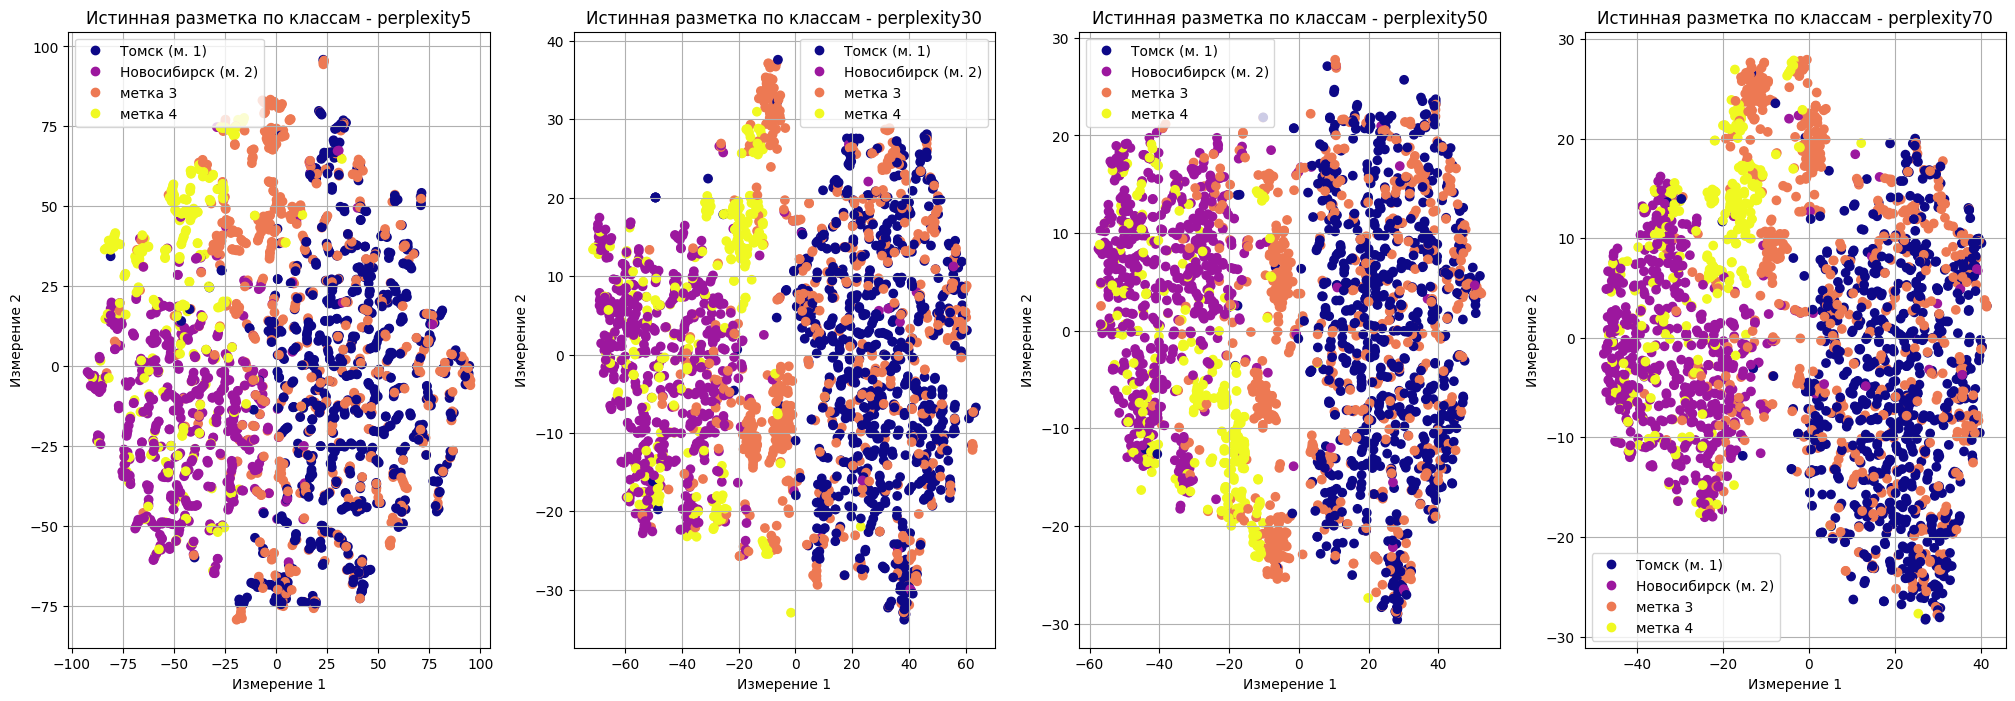

In [ ]:
perplexity=[5, 30, 50, 70]
f, ax = plt.subplots(1, len(perplexity), figsize=(25, 8))
i = 0
for perxt in perplexity:
  tsne = TSNE(n_components=2, verbose=0, perplexity=perxt, metric='cosine' )
  tsne_results = tsne.fit_transform(np.array(X_emb))
  scat1 = ax[i].scatter(x = tsne_results[:, 0], y = tsne_results[:, 1], c = values, cmap='plasma')
  ax[i].set_xlabel('Измерение 1')
  ax[i].set_ylabel('Измерение 2')
  ax[i].set_title('Истинная разметка по классам - perplexity' + str(perxt))
  ax[i].legend(handles=scat1.legend_elements()[0], labels=['Томск (м. 1)', 'Новосибирск (м. 2)', 'метка 3', 'метка 4'])
  ax[i].grid(True)
  i= i+1
plt.show()

In [ ]:
       # вставить выбранное значение perplexity
tsne = TSNE(n_components=2, verbose=0, perplexity=50, metric='cosine' )
tsne_results = tsne.fit_transform(np.array(X_emb))

In [ ]:
#выполнить kmodes при помощи функции
#Входными данным в данном случае являются tsne_results
#find_optimal_clusters() # самостоятельно задать параметры

In [ ]:
#оценить результат по лучшим данным полученным на предыдущем шаге
# 2 по силуэту, 3 по AMI
#kmedoids = KMedoids(n_clusters= , random_state=14).fit(tsne_results)
#draw_cluster(tsne_results, kmedoids.labels_, values)

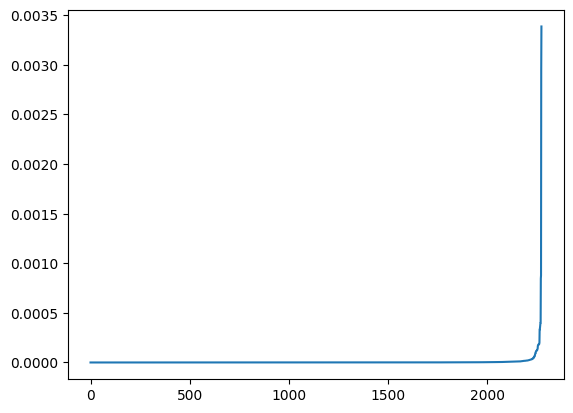

In [ ]:
# для dbscan подберем eps по плечу
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=40, metric="cosine")
neighbors_fit = neighbors.fit(tsne_results)
distances, indices = neighbors_fit.kneighbors(tsne_results)
distances = np.sort(distances, axis=0)
distances = distances[:,1]

plt.plot(distances)

In [ ]:
# Вставьте лучшие значения, полученные на предыдущем шаге и оцените визуальную картину
#db = DBSCAN(eps=, min_samples=, metric='cosine' ).fit(tsne_results)
#draw_cluster(tsne_results, db.labels_, values)

In [ ]:
# вызовите метод подбирающий число кластеров для агломеративного иерархического алгоритма
#Aglomerative_f()

In [ ]:
# Вставьте лучшие значения, полученные на предыдущем шаге и оцените визуальную картину. (Руководствуйтесь критериями качества. Но также можно проверить и пограничные значения.)
#agglomerative = AgglomerativeClustering(n_clusters=,  metric='cosine', linkage='average').fit(tsne_results)
#draw_cluster(tsne_results, agglomerative.labels_, values)